In [1]:
import torch    
import torch_geometric.transforms as T
import mdtraj as md
import os
import torch 
import numpy as np
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import BatchNorm1d
from torch_geometric.nn import GATConv, global_mean_pool, GCNConv, knn_graph, Linear
from torch.optim import SGD, Adam, Optimizer
import math
from torch.nn.init import kaiming_uniform_
from torch_geometric.transforms import ToDevice
import scipy
import sys
from e3nn.io import CartesianTensor
from torch_geometric.loader import DataLoader

device='cuda'
torch.cuda.is_available()

True

In [2]:
torch.norm(torch.tensor([-12.0, 5.4, -9.0]))

tensor(15.9424)

In [2]:
# c: FIXEDATOM AT=0.5915449,0.91589033,26.97987352
# # End point of the axis
# d: FIXEDATOM AT=-0.47780228,-2.338205,-24.90719

colors = ['blue','green','pink','orange','yellow', 'purple', 'red']   
start = np.array([0.5915449,0.91589033,26.97987352])
end = np.array([-0.47780228,-2.338205,-24.90719])

arr = end-start
arr_n = arr/np.linalg.norm(arr)
arr_n

array([-0.02056437, -0.06257876, -0.99782814])

In [5]:
ps = []
for i in [5,10,15,20,25,30,35]:
    p = start + i*arr_n
    ps.append(p)
for c, p in zip(colors, ps):
    print("draw color %s" %c)
    print("draw sphere {",p[0],p[1],p[2],"} radius 1")

draw color blue
draw sphere { 0.4887230557794334 0.6029965483002782 21.990732797418133 } radius 1
draw color green
draw sphere { 0.38590121155886686 0.29010276660055623 17.001592074836267 } radius 1
draw color pink
draw sphere { 0.2830793673383003 -0.0227910150991657 12.012451352254399 } radius 1
draw color orange
draw sphere { 0.1802575231177337 -0.3356847967988875 7.02331062967253 } radius 1
draw color yellow
draw sphere { 0.07743567889716707 -0.6485785784986094 2.0341699070906607 } radius 1
draw color purple
draw sphere { -0.025386165323399434 -0.9614723601983314 -2.9549708154912047 } radius 1
draw color red
draw sphere { -0.12820800954396605 -1.2743661418980534 -7.944111538073077 } radius 1


In [15]:
0.632166*(10/11) + 0.455 * (1/11)

0.61606

In [6]:
from rdkit import Chem
mol = Chem.MolFromPDBFile("an1.pdb", removeHs=False)
Chem.SanitizeMol(mol)

top ='an1.gro'
Sim=6
t = "../Sim%d/cat_small.dcd"%Sim
traj = md.load(t, top=top)

xyz = torch.tensor(traj.xyz) * 10
ele2num = {"C": 0, "H": 1, "O": 2, "N": 3, "S": 4, "VS": {"FE": 5, "MG":6}} # all 0's will be padding for gases not within 3.5 angstroms of any protein atom
gas='O2QD'
metal='FE'
gas2 = traj.topology.select('resname %s' % gas)
residue_ref = np.array([traj.topology.atom(ind).residue.resSeq for ind in gas2])
FE = traj.topology.select('resname Fe2p')
residue_sel_un = np.unique(residue_ref) # gas
residue_sel_un

print('LEN FE', FE)
residue_sel_un = np.unique(residue_ref) # gas
residue_sel_un
nogas = np.setdiff1d(range(0,traj.xyz.shape[1]),gas2)
rnames = np.array([traj.topology.atom(ind).residue.name for ind in nogas])
rindex = np.array([traj.topology.atom(ind).residue.resSeq for ind in nogas])
anames = np.array([traj.topology.atom(ind).element.symbol for ind in nogas])
anames2=np.array([traj.topology.atom(i).name for i in nogas])
anums = [ele2num[a] if a != 'VS' else ele2num[a][metal] for a in anames]

rnames = np.array([traj.topology.atom(ind).residue.name for ind in nogas])
rindex = np.array([traj.topology.atom(ind).residue.resSeq for ind in nogas])
anames = np.array([traj.topology.atom(ind).element.symbol for ind in nogas])
rnames2 = np.array([traj.topology.atom(ind).residue for ind in nogas])

cat = np.where(anames=='VS')[0]
cat

device = torch.device("cpu")
# device = torch.device("cpu")
protein_coords_traj = xyz[:,nogas,:]
rs = int(len(residue_ref)/len(residue_sel_un))
gas_atoms=gas2.reshape(len(residue_sel_un),3)

dioxygen_coords_ave = xyz[:,gas2,:].reshape(-1,len(residue_sel_un),rs,3).mean(axis=2)
d=torch.cdist(dioxygen_coords_ave, xyz[:,cat,:])
diox = np.where(d < 6.0)[1]
frames = np.where(d < 6.0)[0]

types_array_atom = torch.zeros((len(nogas)+len(gas2), (len(ele2num))))
for i, t in enumerate(anums):
    types_array_atom[i,t] = 1.0
# types_array_atom.shape
types_array_atom[-len(gas2):,ele2num['O']] = 1
types_array_atom = types_array_atom.to(device)

gas_idx = np.where(residue_sel_un==250000)[0]
gas_idx
protein_cofactors = torch.tensor(nogas).to(device)
global_to_local = {int(g): i for i, g in enumerate(np.arange(0,xyz[:,nogas,:].shape[1]))}

del traj

t = "../Sim16/cat_small.dcd"
traj = md.load_frame(t, index=0,top=top )

/home/coyote/miniconda3/envs/holoprot/lib/python3.10/site-packages/mdtraj/formats/gro.py:364: UserWarning: WARNING: two consecutive residues with same number (GLN, ACE)
  warnings.warn(
/home/coyote/miniconda3/envs/holoprot/lib/python3.10/site-packages/mdtraj/formats/gro.py:364: UserWarning: WARNING: two consecutive residues with same number (ASP, ACE)
  warnings.warn(


LEN FE [3790]


In [14]:
# types_array_atom.shape
from torch_geometric.data import Data
def extract_point_cloud(atom_matrix, positions, center):
    """
    Formats the already-cropped atom features and positions into a Data object.
    """
    if positions.shape[0] == 0:
        return None  # Skip empty cubes

    # Center coordinates relative to cube center
    centered_positions = positions - center

    return Data(x=atom_matrix, pos=centered_positions)

path_dict = {
    'P1':'P1', 
    'P_main (PmR)':'PmR', 
    'P_main (mid)':'mid', 
    'P_reverse':'P_reverse', 
    'P_main (PmL)':'PmL',
       'P3':'P3'
}

def write_pdb2(inds, what, xs, ys, zs, chain='C', file="ml_out.pdb"):
    
    print(file)
    
    fpdb = open(file, 'wt')
    norm = torch.max(what[inds])
    i_atom = 1
    i_resid = 1
    for i, dind in enumerate(inds):

        fpdb.write('{:6s}{:5d} {:^4s}{:1s}{:3s} {:1s}{:4d}{:1s}   {:8.3f}{:8.3f}{:8.3f}{:6.2f}{:6.2f}          {:>2s}{:2s}\n'.format(
            'ATOM',i_atom,
            'GG','','GG',
            chain,i_resid,'',
            xs[dind],ys[dind],zs[dind],
            -1.0*torch.log10(what[dind]/norm),(what[dind]),
            'K',''))
        i_atom += 1
        if i_atom > 999:
            i_atom = 1
            i_resid += 1
            #eigv[dind,0],mm.pi[dind],
    fpdb.write('TER\n')
    fpdb.close()

def get_points(start, translated, frame_pos, space=0.65, bottom_threshold=2.5, top_threshold=3.5, radius=4.5, distance_to=20):
    if distance_to <= 12:
        x_edges = np.arange(-16, 16, space)
        y_edges = np.arange(-16, 16, space)
        z_edges = np.arange(-16, 16, space)
    elif distance_to <= 9:
        x_edges = np.arange(-13, 13, space)
        y_edges = np.arange(-13, 13, space)
        z_edges = np.arange(-13, 13, space)
    else:
        x_edges = np.arange(-20, 21, space)
        y_edges = np.arange(-20, 21, space)
        z_edges = np.arange(-20, 21, space)

    X, Y, Z = np.meshgrid(x_edges, y_edges, z_edges, indexing='ij')

    # Stack the arrays to create a 3D array of shape (N, 3)
    points_3d = torch.tensor(np.stack([X, Y, Z], axis=-1).reshape(-1, 3), dtype=torch.float32)

    translated_ang = translated.clone()
    exclude_points = translated_ang


    threshold = bottom_threshold
    threshold2 = top_threshold

    # Compute distances from every point in `points_3d` to every `exclude_point`
    distances=torch.cdist(points_3d, exclude_points)

    # Find points in `points_3d` with all distances >= threshold
    mask = torch.all(distances >= threshold, axis=1)
    mask2 = torch.any(distances < threshold2, axis=1)

    # Filter `points_3d` to keep only points outside the threshold
    filtered_points = points_3d[mask & mask2]

    filtered_points2 = filtered_points# + protein_coords_list.cpu()[cat].numpy() 
    filtered_points2.mean(axis=0)
    filtered_points2.shape
    dist2 = torch.norm(filtered_points2-frame_pos, dim=1)
    if start==0:
        filtered_points3 = filtered_points2[dist2 <= 20]
    else:
        filtered_points3 = filtered_points2[dist2 <= radius]
    xyz2=filtered_points3

    return xyz2


def get_fe_bias(xyz2, frame_pos, alpha=10.0, beta=1.0, denom=4, range_=0.75):
    """
    alpha → dominance of origin distance
    beta  → influence of closeness to the line
    """

    # ------------------------------
    # Distance to origin (dominant term)
    # ------------------------------
    dist_origin = torch.norm(xyz2, dim=1)  # [N]
    # Invert + square for extreme emphasis (close gets very large)
    origin_score = 1.0 / (dist_origin**denom + 1e-8)

    # ------------------------------
    # Distance to line
    # ------------------------------
    line_dir = frame_pos / torch.norm(frame_pos)
    t = (xyz2 * line_dir).sum(dim=1, keepdim=True)
    d_perp = torch.norm(xyz2 - t * line_dir, dim=1)

    # Invert perpendicular distance
    line_score = 1.0 / (d_perp + 1e-8)

    # ------------------------------
    # Combine WITHOUT global normalization
    # (so origin dominance is preserved)
    # ------------------------------
    combined = alpha * origin_score + beta * line_score

    # ------------------------------
    # Scale result to 0–0.5 while preserving ranking
    # ------------------------------
    combined_min = combined.min()
    combined_max = combined.max()

    score = range_ * (combined - combined_min) / (combined_max - combined_min + 1e-8)

    return score

import torch
def get_best(density, pos_embedding, k=5):
# points: [N,3], density: [N]
    # k = 5
    points = torch.stack([p.center for p in pos_embedding])
    # density=density
    N = points.shape[0]

    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # compute distances from point i
        dists = torch.norm(points - points[i], dim=1)  # [N]
        
        # find indices of the closest k points including self
        _, nn_idx = torch.topk(-dists, k)  # negative because topk returns largest
        
        # sum densities in this group
        group_density = density[nn_idx].sum()
        scores[i] = {}
        scores[i]['group_density'] = group_density
        scores[i]['nn_idx'] = nn_idx
        
        if group_density > best_sum:
            best_sum = group_density
            best_group = nn_idx
            best_ndx = i

    highest_cluster_points = points[best_group]
    highest_cluster_density = density[best_group]

    return scores, points


def embed(xyz2, step, protein_coords_list,protein_cofactors,global_to_local, radius=5, frame_emb=None):
    print("STEP:", step)
    # xyz2:  grid point coordinates for the frame we are trying to predictt, i.e. the next frame, 
    # frame_pos: the given O2 in frame 0
    # first frame frame_pos for O2 is given, each one after is prediction from one before
    # 0 is first step which is given and we start to predict from 1

    pos_embedding = []
    xyz = []
    atom_coords = protein_coords_list
    
    # print(dist)
    min_dist = 2.5
    
    for i, point in enumerate(xyz2[0:]):
        center = point
        dist = torch.norm(center - atom_coords[cat[0],:])
      
      
        # radius = 6.0

        # Compute distances of all atoms to perturbed point
        dists = torch.norm(atom_coords - center, dim=1)

        # Indices of atoms inside sphere
                    # Indices of atoms inside sphere
        inside_indices = protein_cofactors[torch.where(dists <= radius)[0]]

        # Ensure inside_indices is always a 1D tensor
        if torch.is_tensor(inside_indices) and inside_indices.ndim == 0:
            inside_indices = inside_indices.unsqueeze(0)

        if isinstance(inside_indices, (int, np.integer)):
            inside_indices = torch.tensor([inside_indices], device=device)

        if inside_indices.numel() == 0:
            dddd = torch.cdist(center.unsqueeze(0), atom_coords)
            print('too far start or end', dddd.min(), flush=True)
            continue
        xyz.append(i)
        local_inside_indices = np.array([global_to_local[int(g)] for g in inside_indices])

        atom_matrix=types_array_atom[inside_indices]
        positions=atom_coords[local_inside_indices]
        node_directions = positions - atom_coords[cat[0],:]
        node_distances = torch.norm(node_directions, dim=1)
        local_pos_normalized = (positions - center)/radius  # shape [N, 3]
        
        # atom_matrix_arr.append(atom_matrix)
        # positions_arr.append(positions)
        test = extract_point_cloud(atom_matrix, positions, center)
        # test.x=torch.column_stack([test.x, torch.tensor(frame_emb[idx]).repeat(len(test.x))])
        if frame_emb is not None:
            frame_vector = frame_emb[step]          # [16]
            frame_vector = frame_vector.unsqueeze(0)           # [1, 16]
            frame_vector = frame_vector.expand(len(test.x), -1)  # [N, 16]
            test.distance = dist.expand(len(test.x))
            test.x = torch.cat([test.x, frame_vector], dim=1)    # [N, 6 + 16]

        test.edge_index, test.edge_attr = build_edges_and_attrs(inside_indices)
        test.inside_indices = inside_indices
        test.center = center
        test.node_attr = local_pos_normalized
        test.node_directions = node_directions
        test.node_distances = node_distances
        pos_embedding.append(test)
    print("DOEN")
    xyz2 = xyz2[xyz]
    return xyz2, pos_embedding

def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold=0.5):
    density = density.to('cpu')
    points = torch.stack([p.center for p in pos_embedding])
    keep = torch.where(density > threshold)[0]
    while len(keep) < (3*k):
        print(len(keep),threshold)
        threshold = threshold/2
        
        keep = torch.where(density > threshold)[0]
        print(len(keep),threshold)
    points = points[keep]
    density = density[keep]
    print(density.shape)
    N = points.shape[0]
    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]
        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
                best_group = nn_idx
                best_ndx = i
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points

# Map from global RDKit atom idx → local 0..N-1
import itertools

def build_edges_and_attrs(inside_indices):
    atom_to_local = {int(a): i for i, a in enumerate(inside_indices.tolist())}

        # --- Extract bonded edges from RDKit ---
    bonded_edges = []
    bonded_attrs = []

    for bond in mol.GetBonds():
        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()

        # Only keep if both atoms are in the subset
        if a1 in atom_to_local and a2 in atom_to_local and a1 not in gas_atoms and a2 not in gas_atoms:
            i1, i2 = atom_to_local[a1], atom_to_local[a2]

            bt = bond.GetBondType()
            if bt == Chem.rdchem.BondType.SINGLE:
                order = 1
            elif bt == Chem.rdchem.BondType.DOUBLE:
                order = 2
            elif bt == Chem.rdchem.BondType.AROMATIC:
                order = 3
            else:
                order = 1

            # undirected edges
            bonded_edges += [[i1, i2], [i2, i1]]
            bonded_attrs += [order, order]

    for (a1, anot ,a2) in gas_atoms:
        if a1 in atom_to_local and a2 in atom_to_local:
            i1, i2 = atom_to_local[a1], atom_to_local[a2]
            bonded_edges += [[i1, i2], [i2, i1]]
            bonded_attrs += [1, 1]

    # --- Build nonbonded edges among all pairs in subset ---
    N = len(inside_indices)
    all_pairs = list(itertools.combinations(range(N), 2))

    bonded_set = set(tuple(sorted(e)) for e in [(a, b) for a, b in bonded_edges if a < b])

    nonbonded_edges = []
    nonbonded_attrs = []

    for i, j in all_pairs:
        if (i, j) not in bonded_set:
            nonbonded_edges += [[i, j], [j, i]]
            nonbonded_attrs += [0, 0]  # edge_attr = 0 for nonbonded

    # --- Combine everything ---
    # edge_index = torch.tensor(bonded_edges + nonbonded_edges, dtype=torch.long).T
    edges = bonded_edges + nonbonded_edges  # list of [i, j] pairs
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(bonded_attrs + nonbonded_attrs, dtype=torch.long)

    return edge_index, edge_attr.unsqueeze(1)

import torch
import math

def predict(pos_embedding, model, bs=5, frame_emb_bool=False, node_input_bool=False, atom_as_node_attr=False):
    # model = torch.load('../Sim1/model.pt') # 
    # model=torch.load("../Sim5/model%d_FE2dis_inr6.pt"%24)
    model=torch.load(model)
    device='cuda'
    model = model.to(device)


    test_loader = DataLoader(pos_embedding, batch_size=bs, shuffle=False) 


    values = []
    with torch.no_grad():
        for batch_idx, (data_list) in enumerate(test_loader):
            if (batch_idx + 1) % 20 == 0:
                print("Batch",batch_idx+1, flush=True)
            if isinstance(data_list, list):
                from torch_geometric.data import Batch
                batch = Batch.from_data_list(data_list)
            else:
                batch = data_list  # if batch_size=1, it might already be a Data object

            batch = batch.to('cuda')
            

            
            distance = torch.norm(batch.node_attr[:, :3], dim=1, keepdim=True)  # [N, 1]

            # 2. Convert Cartesian vectors to irreps vector
            x = CartesianTensor("i")
            vector_irrep = x.from_cartesian(batch.node_attr[:, :3])  # [N, 3]

          
            atom_type_onehot = batch.x[:, 0:6]
            
            frame_emb = batch.x[:, 6:] 
            if frame_emb_bool:
                if atom_as_node_attr:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        atom_type_onehot,    # 6 scalars (0e)
                        frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)
                else:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        # atom_type_onehot,    # 6 scalars (0e)
                        frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)

            else:
                # node_attr = torch.cat([distance, vector_irrep, frame_emb], dim=1)
                if atom_as_node_attr:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        atom_type_onehot,    # 6 scalars (0e)
                        # frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)
                else:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        # atom_type_onehot,    # 6 scalars (0e)
                        # frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)

            
            # node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)
            if node_input_bool:
                node_input = torch.cat([
                    # batch.distance.unsqueeze(-1), # 1 scalar (0e) distance of center of graph to iron
                    batch.node_distances.unsqueeze(-1),    # 1 scalar (0e) distance to iron for each atom
                    F.normalize(batch.node_directions, p=2, dim=1),        # 3-vector (1o) direction to iron for each atom
                ], dim=1)
            else:
                node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)

            if not atom_as_node_attr:
                data = {
                "batch": batch.batch,
                # "x": batch.x[:,0:6], # atom type
                # "frame_emb": frame,
                "x": atom_type_onehot,
                "node_attr": node_attr, 
                "edge_index": batch.edge_index,
                "edge_attr": batch.edge_attr,
                "pos": batch.pos,  # if needed in preprocess
            }
            else:
                data = {
                    "batch": batch.batch,
                    # "x": batch.x[:,0:6], # atom type
                    # "frame_emb": frame,
                    "x": node_input,
                    "node_attr": node_attr, 
                    "edge_index": batch.edge_index,
                    "edge_attr": batch.edge_attr,
                    "pos": batch.pos,  # if needed in preprocess
                }

            outputs = model(data)
            preds = torch.sigmoid(outputs.squeeze(-1))
            values.append(preds)

        results = torch.concat(values)
        best = results.argmax() # 2552
        best_pos = best#xyz2[best]
        return best, best_pos, results

def sinusoidal_embedding(frame_idx: torch.Tensor, dim: int = 16):
    """
    frame_idx: tensor of shape [N] with normalized frame values in [0,1]
    dim: embedding dimension (should be even)
    Returns: tensor of shape [N, dim]
    """
    device = frame_idx.device
    N = frame_idx.size(0)
    pe = torch.zeros(N, dim, device=device)

    position = frame_idx.unsqueeze(1)  # [N, 1]
    div_term = torch.exp(torch.arange(0, dim, 2, device=device) * -(math.log(10000.0) / dim))  # [dim/2]

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # [N, dim]

    

In [47]:
end=150
start=0
frames = torch.arange(0, end, dtype=torch.float32)  # [0,1,...,N-1]
frame_norm = frames / (end - start)    
frame_emb = sinusoidal_embedding(frame_norm, dim=16)

In [ ]:
colors = ['blue','green','black','orange','yellow']                                               

# end=len(traj)
# frames = torch.arange(0, end, dtype=torch.float32)  # [0,1,...,N-1]
# frame_norm = frames / (end - start)    
# frame_emb = sinusoidal_embedding(frame_norm, dim=16) 
frame_pos_bests = []
frame_pos_bests_dist = []

frame_pos=torch.tensor([5.2800, 16.0400,  1.4000]) # pr
# frame_pos=torch.tensor([8.,8.,10.]) # pr2
# frame_pos=torch.tensor([-13.12, -11.44, -0.24]) # pmain
frame_pos=torch.tensor([-14.16, -8.04, -6.04]) # pmain frame 19900  draw sphere { -14.16 -8.04 -6.04 } radius 1; draw sphere { -11.16 -12.04 -0.2 } radius 1
# frame_pos=torch.tensor([12., -1., -6.]) #p4
# frame_pos=torch.tensor([10.48, -6.2, -4.32]) #p4
# draw sphere { 10.48 -6.2 -4.32 } radius 1
# draw sphere { -3.6 -4.24 -18.16 } radius 1
# draw sphere { 4.28 -13.36 -7.36 } radius 1
# draw sphere { 4.52 -6.64 -12.72 } radius 1
# frame_pos=torch.tensor([13., 1., -5.]) #p4
# frame_pos=torch.tensor([12.379090, -6.340079, -7.980374]) #p4
# frame_pos=torch.tensor([3.84, -5.12, -12.96]) #p4 frame 1000
frame_pos=torch.tensor([5.4, 2.2, -12.0]) #p4 frame 1000
frame_pos=torch.tensor([-0.9, -13.6, 14.4])# pmain 1000
frame_pos=torch.tensor([-14.3, 4.9, -10.2]) # p3 1000 Sim6 draw sphere { -14.3 4.9 -10.2 } radius 1
# frame_pos=torch.tensor([8.5, 7.5, 9.5])# pr 1000
# frame_pos=torch.tensor([9.32, 7.36, 9.56]) #pRev frame 1000
# frame_pos=torch.tensor([6.24, -4.16, -12.12]) #p4 frame 0
# frame_pos=torch.tensor([-3.56, -6.76, -16.76]) #p4 frame 19000 #2
# frame_pos=torch.tensor([7.96, -2.04, -10.76]) #p4  10000 { 7.96 -2.04 -10.76 } radius 1 : p4 higher (curved??)
# frame_pos=torch.tensor([-10.0, -9.3, -3.3]) #pm frame 2500 sim6
# frame_pos=torch.tensor([10.92, 9.84, 8.64]) #pRev  10000 Sim6?? all above Sim6?

 
# frame_pos=torch.tensor([-10.625, -11.675, -4.475]) #pm2 frame 10000 sim16
# frame_pos=torch.tensor([2.7 -5.2 -13.6]) #p4 frame 5000 sim16
# frame_pos=torch.tensor([-1.1, -12.9, -3.9 ]) #p2 frame 5000 sim16
# frame_pos=torch.tensor([-12.8, -3.4, 2.3]) #pm1 frame 5000 sim16
# frame_pos=torch.tensor([11.725, 1.825, 13.6]) #pr1 frame 10000 sim16; draw sphere { 5.425 -2.0 19.975 } radius 1 : pr2
# frame_pos=torch.tensor([8.425, 9.888, 16.092])
# frame_pos=torch.tensor([7.3, 10.1, 12.9]) #pr1 frame 20000 sim2
# frame_pos=torch.tensor([9.25, 10.75, 7.75]) #pr frame 20000 sim2 real 24146-24200
space=0.85
distance=torch.norm(frame_pos)
start=1100
# start=start=19901
step=100
# frame_pos=torch.tensor([4.75, 12.5, 2.0])
frame_pos=torch.tensor([5.6, 2.8, -4.4])
for start in range(start+0,start+49):
    distance=torch.norm(frame_pos)
    torch.cuda.empty_cache()
    color=colors[start % 5]
    print("START:", start)
    protein_coords_traj = xyz[start,nogas,:]
    translated = protein_coords_traj - protein_coords_traj.cpu()[cat].numpy() 
    
    new_traj = md.Trajectory(xyz=((xyz[start]-protein_coords_traj.cpu()[cat].numpy())/10).numpy(), topology=traj.topology)
    new_traj.save('translated_frame%d_Sim%d.pdb'%(start,Sim))

    protein_coords_traj2 = xyz[start+1,protein_cofactors,:]
    translated2 = protein_coords_traj2 - protein_coords_traj2.cpu()[cat].numpy()

    

    if distance > 12:
        xyz2=get_points(start, translated, frame_pos, space=space, bottom_threshold=2., top_threshold=4.5, radius=5)
    else:
        if distance < 9:
            space=0.4
            radius=3
        else:
            space=0.65
            radius=4
        print("SPACE:",space)
        xyz2=get_points(start, translated, frame_pos, space=space, bottom_threshold=1.9, top_threshold=4.5, radius=radius, distance_to=distance)
    print(xyz2.shape)
    if xyz2.shape[0] < 6:
        xyz2=get_points(start, translated, frame_pos, space=0.45, bottom_threshold=2.1)
        print(xyz2.shape)
# embed_predict and get highest next point to be the next frame_pos at 2...end
    
    if distance >= 2:
        xyz2, pos_embedding = embed(xyz2, step=step, protein_coords_list=translated,protein_cofactors=protein_cofactors,global_to_local=global_to_local, radius=6, frame_emb=frame_emb)
    else:
        xyz2, pos_embedding = embed(xyz2, frame_emb, step=step, protein_coords_list=translated,protein_cofactors=protein_cofactors,global_to_local=global_to_local, radius=5)
    xyz2 = torch.stack([j for i,j in zip(pos_embedding,xyz2) if len(i.edge_index) > 0])
    pos_embedding = [i for i in pos_embedding if len(i.edge_index) > 0]
    print(xyz2.shape)
    
    
    if distance >= 2:
        print('#################################')
        # index, frame_pos__, results1 = predict(pos_embedding, model='../Sim5/model30_FE2dis_inr7.pt', bs=2)
        torch.cuda.empty_cache()
        index, frame_pos__, results2 = predict(pos_embedding, model='../Sim5/model17_FE2dis_inr3.pt', bs=5,frame_emb_bool=True, node_input_bool=False, atom_as_node_attr=False)
        torch.cuda.empty_cache()
        # index, frame_pos__, results2 = predict(pos_embedding, model='../Sim5/model39_FE2dis_inrPmP4_far.pt', bs=3)
        results = results2# + results2
    else:
        index, frame_pos__, results1 = predict(pos_embedding, model='../Sim5/model30_FE2dis_inr7.pt', bs=2) # inputs are from pos/neg_embedding_in3.pt with some close negatives
        torch.cuda.empty_cache()
        # index, frame_pos__, results2 = predict(pos_embedding, model='../../../PCOs/O2IF/Sim5/model15_FE2dis_inr5.pt')
        results = results1 #+ results2
    # index, frame_pos__, results = predict(pos_embedding, model='../Sim5/model27_FE2dis_inr7PM.pt')
    # break

    # bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.0001, denom=4, range_=0.25)
    # results_biased = results * (1+bias.to('cuda'))
    # scores, points = topk_with_radius(results_biased, pos_embedding, k=10, radius=4)

    # bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.001, denom=4, range_=0.5)
    # results_biased = results * (1+bias.to('cuda'))
    # scores, points = topk_with_radius(results_biased, pos_embedding, k=10, radius=4)
    
    # bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.0001, denom=2, range_=0.25)
    # bias=get_fe_bias(xyz2, frame_pos, alpha=50.0, beta=0.00001, denom=2, range_=0.15)
    bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.001, denom=4, range_=1.)
    results_biased = results * (1+bias.to('cuda'))
    total_positives = (results_biased>0.5).sum()
    if len(pos_embedding) < 400:
        if distance < 10 and total_positives < 5:
            print("k=1")
            scores, points = topk_with_radius(results_biased, pos_embedding, k=1, radius=1, threshold=0.5)
        else:
            print("k=3")
            scores, points = topk_with_radius(results_biased, pos_embedding, k=3, radius=2, threshold=0.5)
    else:
        print("k=3, len(pos_embedding)", len(pos_embedding))
        scores, points = topk_with_radius(results_biased, pos_embedding, k=3, radius=3, threshold=0.5)

    top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
    for key, vals in top10:
        frame_pos=points[vals['nn_idx']].mean(axis=0)
        print("draw color %s" % color)
        # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
        print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 0.5")

    # frame_pos=predict(pos_embedding)
    # start+=1
    
    frame_pos_bests.append(frame_pos)
    frame_pos_bests_dist.append(torch.norm(frame_pos))
    write_pdb2(torch.arange(0,len(pos_embedding)),results,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '.pdb')
    write_pdb2(torch.arange(0,len(pos_embedding)),results_biased,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '_biased.pdb')
    write_pdb2(torch.arange(0,len(pos_embedding)),bias,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '_bias.pdb')
    print('translated_frame%d_Sim%d.pdb'%(start,Sim))
    step+=1

    print("\tDistance to iron:", frame_pos_bests_dist[-1])
    
    d2=torch.norm(translated-frame_pos, dim=1)
    d3=torch.norm(translated2-frame_pos, dim=1)
    try:
        print("\tClosest atom this frame %s, %s: %f" % (rnames2[d2.argmin()], anames2[d2.argmin()], d2.min()))
        print("\tClosest atom next frame %s, %s: %f" % (rnames2[d3.argmin()], anames2[d3.argmin()], d3.min()))
    except:
        print("Closest or another oxygen")
    if frame_pos_bests_dist[-1] > 21:
        break
    if frame_pos_bests_dist[-1] < 6:
        break



START: 1100
SPACE: 0.4
torch.Size([71, 3])
STEP: 100
DOEN
torch.Size([71, 3])
#################################
k=3
torch.Size([16])
draw color blue
draw sphere { 5.2 2.9333334 -5.0666666 } radius 0.5
1100_Sim6_frame100_of_150.pdb
1100_Sim6_frame100_of_150_biased.pdb
1100_Sim6_frame100_of_150_bias.pdb
translated_frame1100_Sim6.pdb
	Distance to iron: tensor(7.8304)
	Closest atom this frame ARG312, HG3: 2.240109
	Closest atom next frame HIS313, N: 2.094389
START: 1101
SPACE: 0.4
torch.Size([123, 3])
STEP: 101
DOEN
torch.Size([123, 3])
#################################


In [32]:
# if distance >= 2:
#     print('#################################')
#     # index, frame_pos__, results1 = predict(pos_embedding, model='../Sim5/model30_FE2dis_inr7.pt', bs=2)
#     torch.cuda.empty_cache()
#     index, frame_pos__, results2 = predict(pos_embedding, model='../Sim5/model11_FE2dis_inr3.pt', bs=5,frame_emb_bool=True, node_input_bool=False, atom_as_node_attr=False)
#     torch.cuda.empty_cache()
#     # index, frame_pos__, results2 = predict(pos_embedding, model='../Sim5/model39_FE2dis_inrPmP4_far.pt', bs=3)
#     results = results2# + results2
# else:
#     index, frame_pos__, results1 = predict(pos_embedding, model='../Sim5/model30_FE2dis_inr7.pt', bs=2) # inputs are from pos/neg_embedding_in3.pt with some close negatives
#     torch.cuda.empty_cache()
#     # index, frame_pos__, results2 = predict(pos_embedding, model='../../../PCOs/O2IF/Sim5/model15_FE2dis_inr5.pt')
#     results = results1 #+ results2
# index, frame_pos__, results = predict(pos_embedding, model='../Sim5/model27_FE2dis_inr7PM.pt')
# break

# bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.0001, denom=4, range_=0.25)
# results_biased = results * (1+bias.to('cuda'))
# scores, points = topk_with_radius(results_biased, pos_embedding, k=10, radius=4)

# bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.001, denom=4, range_=0.5)
# results_biased = results * (1+bias.to('cuda'))
# scores, points = topk_with_radius(results_biased, pos_embedding, k=10, radius=4)

# bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.0001, denom=2, range_=0.25)
# bias=get_fe_bias(xyz2, frame_pos, alpha=50.0, beta=0.00001, denom=2, range_=0.15)
frame_pos=torch.tensor([-10.366667, -9.8, -3.2833335])
bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.0001, denom=4, range_=2)
results_biased = results * (1+bias.to('cuda'))
total_positives = (results_biased>0.5).sum()
if len(pos_embedding) < 400:
    if distance < 10 and total_positives < 5:
        print("k=1")
        scores, points = topk_with_radius(results_biased, pos_embedding, k=1, radius=3, threshold=0.5)
    else:
        print("k=2")
        scores, points = topk_with_radius(results_biased, pos_embedding, k=2, radius=3, threshold=0.5)
else:
    print("k=3, len(pos_embedding)", len(pos_embedding))
    scores, points = topk_with_radius(results_biased, pos_embedding, k=3, radius=3, threshold=0.5)

top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    print("draw color %s" % color)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 0.5")

# frame_pos=predict(pos_embedding)
# start+=1

frame_pos_bests.append(frame_pos)
frame_pos_bests_dist.append(torch.norm(frame_pos))
write_pdb2(torch.arange(0,len(pos_embedding)),results,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '.pdb')
write_pdb2(torch.arange(0,len(pos_embedding)),results_biased,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '_biased.pdb')
write_pdb2(torch.arange(0,len(pos_embedding)),bias,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '_bias.pdb')
print('translated_frame%d_Sim%d.pdb'%(start,Sim))
step+=1

print("\tDistance to iron:", frame_pos_bests_dist[-1])

d2=torch.norm(translated-frame_pos, dim=1)
d3=torch.norm(translated2-frame_pos, dim=1)
try:
    print("\tClosest atom this frame %s, %s: %f" % (rnames2[d2.argmin()], anames2[d2.argmin()], d2.min()))
    print("\tClosest atom next frame %s, %s: %f" % (rnames2[d3.argmin()], anames2[d3.argmin()], d3.min()))
except:
    print("Closest or another oxygen")



k=2
torch.Size([63])
draw color black
draw sphere { -10.225 -9.8 -3.0 } radius 0.5
2502_Sim6_frame9_of_150.pdb
2502_Sim6_frame9_of_150_biased.pdb
2502_Sim6_frame9_of_150_bias.pdb
translated_frame2502_Sim6.pdb
	Distance to iron: tensor(14.4772)
	Closest atom this frame GLN239, HB3: 3.257058
	Closest atom next frame TRP258, HE1: 2.783532


In [11]:
scores, points = topk_with_radius(results_biased, pos_embedding, k=3, radius=3, threshold=0.5)

torch.Size([28])


In [10]:
def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold=0.5):
    density = density.to('cpu')
    points = torch.stack([p.center for p in pos_embedding])
    keep = torch.where(density > threshold)[0]
    while len(keep) < (3*k):
        print(len(keep),threshold)
        threshold = threshold/2
        
        keep = torch.where(density > threshold)[0]
        print(len(keep),threshold)
    points = points[keep]
    density = density[keep]
    print(density.shape)
    N = points.shape[0]
    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]
        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
                best_group = nn_idx
                best_ndx = i
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points

In [30]:
points

tensor([[-5.0000,  2.5000, -8.0000],
        [-4.2500,  2.5000, -8.7500],
        [-0.5000,  3.2500, -7.2500],
        [ 0.2500,  1.7500, -7.2500],
        [ 0.2500,  1.7500, -6.5000],
        [ 0.2500,  2.5000, -8.0000],
        [ 0.2500,  2.5000, -7.2500],
        [ 0.2500,  3.2500, -7.2500],
        [ 1.0000,  1.7500, -7.2500]])

In [10]:
scores, points = topk_with_radius(results_biased, pos_embedding, k=5, radius=3)
scores

{0: {'group_density': tensor(2.0856, device='cuda:0'),
  'nn_idx': tensor([ 0, 30,  3,  1, 25])},
 1: {'group_density': tensor(1.8061, device='cuda:0'),
  'nn_idx': tensor([ 1,  4, 31,  0,  5])},
 2: {'group_density': tensor(1.3610, device='cuda:0'),
  'nn_idx': tensor([ 2,  7, 34, 33,  6])},
 3: {'group_density': tensor(1.7358, device='cuda:0'),
  'nn_idx': tensor([ 3,  4,  8, 39,  0])},
 4: {'group_density': tensor(1.5438, device='cuda:0'),
  'nn_idx': tensor([4, 1, 3, 9, 5])},
 5: {'group_density': tensor(1.2770, device='cuda:0'),
  'nn_idx': tensor([ 5, 41,  6, 10,  4])},
 6: {'group_density': tensor(1.3261, device='cuda:0'),
  'nn_idx': tensor([ 6,  7,  5, 42, 11])},
 7: {'group_density': tensor(1.4860, device='cuda:0'),
  'nn_idx': tensor([ 7,  6, 12, 43,  2])},
 8: {'group_density': tensor(1.3421, device='cuda:0'),
  'nn_idx': tensor([ 8, 14,  3, 48,  9])},
 9: {'group_density': tensor(1.2508, device='cuda:0'),
  'nn_idx': tensor([ 9, 15,  8, 10,  4])},
 10: {'group_density': te

In [20]:

def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold=0.5):
    density=density.to('cpu')
    points = torch.stack([p.center for p in pos_embedding])
    print(points.shape)
    keep = torch.where(density > threshold)
    points = points[keep]
    print(points.shape)
    density = density[keep]
    N = points.shape[0]
    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]
        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
                best_group = nn_idx
                best_ndx = i
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points


In [96]:
scores, points = topk_with_radius(results_biased, pos_embedding, k=1, radius=3, threshold=0.5)
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    print("draw color %s" % color)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 0.5")

torch.Size([3])
draw color green
draw sphere { -5.7 -4.4 -0.5 } radius 0.5


In [51]:
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
top10

[(27, {'group_density': tensor(3.3142), 'nn_idx': tensor([27, 28, 29])})]

In [53]:
torch.norm(frame_pos)

tensor(10.0842)

In [ ]:
top10

[(16, {'group_density': tensor(2.9238), 'nn_idx': tensor([16, 11, 15,  9])})]

In [22]:
points.shape

torch.Size([58, 3])

In [56]:
def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold = 0.5):
    points = torch.stack([p.center for p in pos_embedding])
    
    keep = torch.where(density >= threshold)[0].to('cpu')
    print(points.device, keep.device)
    points=points[keep]
    density = density.to('cpu')[keep]
    N = points.shape[0]
    best_sum = -1
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]

        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points

In [ ]:
    # bias=get_fe_bias(xyz2, frame_pos, alpha=500.0, beta=0.0001, denom=4, range_=0.25)
    # results_biased = results * (1+bias.to('cuda'))
    # scores, points = topk_with_radius(results_biased, pos_embedding, k=10, radius=4)

In [21]:
frame_pos=torch.tensor([-14.16, -8.04, -6.04])
bias=get_fe_bias(xyz2, frame_pos, alpha=50.0, beta=0.00001, denom=2, range_=0.15)
results_biased = results * (1+bias.to('cuda'))
scores, points = topk_with_radius(results_biased, pos_embedding, k=10, radius=4)

# scores, points = topk_with_radius(results_biased, pos_embedding, k=20, radius=5)
    
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    print("draw color %s" % 'black')
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

draw color black
draw sphere { -10.325 -6.725 -2.975 } radius 1


In [33]:
print(vals['nn_idx'].numpy())
results_biased[vals['nn_idx'].numpy()]
np.linalg.norm(frame_pos)
top10

[916 915 893 922 914 888 894 921 887 841 909 879 913 908 919 842 833 840
 920 886]


[(916,
  {'group_density': tensor(37.9212, device='cuda:0'),
   'nn_idx': tensor([916, 915, 893, 922, 914, 888, 894, 921, 887, 841, 909, 879, 913, 908,
           919, 842, 833, 840, 920, 886])})]

In [17]:
# scores, points = topk_with_radius(results, pos_embedding, k=20, radius=5)
print(scores[914]['nn_idx'].numpy())
scores[916]

[914 921 915 913 887 908 922 920 888 916 878 909 886 893 919 879 832 912
 820 885]


{'group_density': tensor(33.0596, device='cuda:0'),
 'nn_idx': tensor([916, 915, 893, 922, 914, 888, 894, 921, 887, 841, 909, 879, 913, 908,
         919, 842, 833, 840, 920, 886])}

In [29]:
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:5]
# print(top10[4][1]['nn_idx'].numpy())
top10

[(922,
  {'group_density': tensor(18.4399, device='cuda:0'),
   'nn_idx': tensor([922, 921, 919, 915, 909, 914, 916, 908, 920, 888])}),
 (915,
  {'group_density': tensor(18.3757, device='cuda:0'),
   'nn_idx': tensor([915, 909, 914, 916, 922, 888, 908, 887, 879, 919])}),
 (921,
  {'group_density': tensor(17.7167, device='cuda:0'),
   'nn_idx': tensor([921, 920, 914, 922, 919, 923, 913, 908, 915, 916])}),
 (914,
  {'group_density': tensor(17.6992, device='cuda:0'),
   'nn_idx': tensor([914, 913, 908, 915, 921, 887, 909, 888, 916, 886])}),
 (881,
  {'group_density': tensor(17.2728, device='cuda:0'),
   'nn_idx': tensor([881, 880, 826, 910, 882, 877, 876, 838, 827, 825])})]

In [34]:
xyz2=get_points(start, translated, frame_pos, space=0.75, bottom_threshold=2.25, top_threshold=5.5, radius=8)

   
xyz2, pos_embedding = embed(xyz2, frame_emb, step=step, protein_coords_list=translated,protein_cofactors=protein_cofactors,global_to_local=global_to_local)
# xyz2 = torch.stack([j for i,j in zip(pos_embedding,xyz2) if len(i.edge_index) > 0])
# pos_embedding = [i for i in pos_embedding if len(i.edge_index) > 0]
# 

STEP: 2
too far start or end tensor(5.4642)
too far start or end tensor(5.1960)
too far start or end tensor(5.1298)
too far start or end tensor(5.2889)
too far start or end tensor(5.3360)
too far start or end tensor(5.0359)
too far start or end tensor(5.1536)
too far start or end tensor(5.1374)
too far start or end tensor(5.3676)
too far start or end tensor(5.1079)
too far start or end tensor(5.3896)
too far start or end tensor(5.1398)
too far start or end tensor(5.2226)
too far start or end tensor(5.2682)
too far start or end tensor(5.4785)
too far start or end tensor(5.1155)
too far start or end tensor(5.4508)
too far start or end tensor(5.4520)
too far start or end tensor(5.4075)
too far start or end tensor(5.0227)
too far start or end tensor(5.3229)
too far start or end tensor(5.0698)
too far start or end tensor(5.2618)
too far start or end tensor(5.4119)
too far start or end tensor(5.2092)
too far start or end tensor(5.1096)
too far start or end tensor(5.1191)
too far start or end

In [37]:
xyz2_2 = torch.stack([j for i,j in zip(pos_embedding,xyz2) if len(i.edge_index) > 0])

In [38]:
pos_embedding_2 = [i for i in pos_embedding if len(i.edge_index) > 0]

In [39]:
xyz2_2.shape

torch.Size([1262, 3])

In [40]:
len(pos_embedding_2)

1262

In [29]:
torch.stack([i.center for i in pos_embedding_2])

tensor([[ 4.7500, -6.5000, -8.0000],
        [ 4.7500, -6.5000, -7.2500],
        [ 4.7500, -5.7500, -8.0000],
        ...,
        [18.2500, -3.5000, -2.0000],
        [18.2500, -2.7500, -3.5000],
        [18.2500, -2.7500, -2.7500]])

In [9]:
points

tensor([[ 8.5000, -8.0000, -9.5000],
        [ 8.5000, -8.0000, -8.7500],
        [ 8.5000, -8.0000, -8.0000],
        ...,
        [14.5000, -5.7500, -4.2500],
        [14.5000, -5.0000, -4.2500],
        [14.5000, -4.2500, -5.0000]])

In [22]:
results.mean()

tensor(1.2356, device='cuda:0')

In [45]:
print(scores[47]['nn_idx'].numpy())
scores[10]

[ 47  46  48 121  52  41  51  42   4  40]


{'group_density': tensor(17.0161, device='cuda:0'),
 'nn_idx': tensor([10, 14, 58,  9,  6,  7, 57, 52, 13, 53])}

In [42]:
# print(vals['nn_idx'].numpy())
top10

[(769,
  {'group_density': tensor(18.2720, device='cuda:0'),
   'nn_idx': tensor([769, 768, 781, 637, 915, 770, 756, 645, 757, 638])})]

In [45]:
print(vals['nn_idx'].numpy())
results_biased[vals['nn_idx'].numpy()]

[111 116  81 112 110 108  82 115 117 109  76  80  89 107  77  75  88  90
 113  62]


tensor([1.0511, 0.9199, 0.4777, 0.9850, 0.7509, 1.0835, 0.9925, 0.6615, 0.9325,
        0.9736, 1.0544, 0.8638, 1.0388, 0.8602, 1.1426, 0.6958, 1.0101, 0.8599,
        1.2002, 1.0647], device='cuda:0')

In [ ]:
# results[6]
# index, frame_pos__, results = predict(pos_embedding, model='../Sim5/model27_FE2dis_inr7PM.pt')
index, frame_pos__, results = predict(pos_embedding, model='../../../PCOs/O2IF/Sim5/model15_FE2dis_inr5.pt')

Batch 20
Batch 40
Batch 60


KeyboardInterrupt: 

In [21]:
# torch.save([torch.tensor([-13.12, -11.44, -0.24])]+ frame_pos_bests, 'pmain.pt')
bests = torch.load('pmain.pt')
len(bests)


False

In [51]:
xyz2=get_points(start, translated, frame_pos, space=0.65, bottom_threshold=2.5)
print(xyz2.shape[0])

0


In [675]:
anames2
rnames2

array([ACE184, ACE184, ACE184, ..., AKG818, AKG818, Fe2p819], dtype=object)

In [679]:
d2=torch.norm(translated_ang-frame_pos, dim=1)
d2.min()

tensor(2.3180)

In [681]:
print("\tClosest atom %s, %s: %f" % (rnames2[d2.argmin()], anames2[d2.argmin()], d2.min()))

	Closest atom TYR565, O: 2.318011


In [658]:
# xyz2[top10['nn_idx']]
# top10
# top10[0][436]
torch.norm(xyz2[top10[0][1]['nn_idx']]-torch.tensor([-9.985000,-7.056000,-2.970000]), dim=1)

tensor([1.5497, 2.1075, 1.2785, 1.7301, 1.9169])

<AxesSubplot:ylabel='Density'>

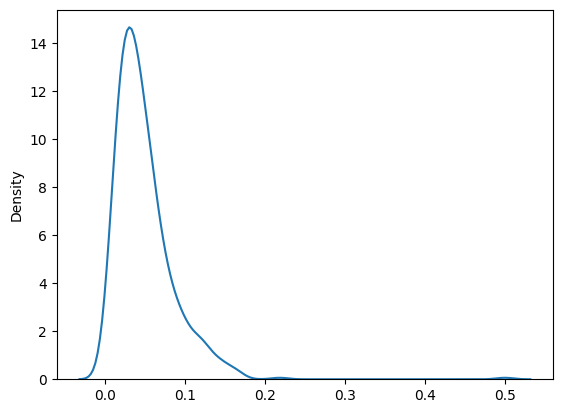

In [ ]:
# import seaborn as sns

sns.kdeplot(bias)

In [ ]:
write_pdb2(torch.arange(0,len(filtered_points3)),results,filtered_points3[:,0],filtered_points3[:,1],filtered_points3[:,2], file=str(start)+ '_frame' + str(step) + '_of_' + str((end)) + '.pdb')

2_frame3_of_50.pdb


In [533]:
frame_pos=torch.tensor([4.75, 12.5, 2.0])
bias=get_fe_bias(xyz2, frame_pos, alpha=50.0, beta=0.005)
results_biased = results * (1+bias.to('cuda'))
scores, points = topk_with_radius(results_biased, pos_embedding,k=3)
# scores, points = get_best(results_biased, pos_embedding)
    
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    print("draw color %s" % color)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

draw color orange
draw sphere { 4.75 12.0 3.75 } radius 1


In [505]:
index, frame_pos__, results = predict(pos_embedding)
bias=get_fe_bias(xyz2, frame_pos, alpha=50.0, beta=0.005)
results_biased = results * (1+bias.to('cuda'))
scores, points = get_best(results_biased, pos_embedding, k=3)

top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    print("draw color %s" % color)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

KeyboardInterrupt: 

In [503]:
print(xyz2[[131, 124, 130]])
print(bias[[131, 124, 130]])
torch.norm(xyz2[[131, 124, 130]], dim=1)

tensor([[ 5.5000, 15.2500,  2.5000],
        [ 5.5000, 14.5000,  2.5000],
        [ 5.5000, 15.2500,  1.7500]])
tensor([0.3455, 0.5518, 0.1697])


tensor([16.4031, 15.7083, 16.3057])

In [ ]:
bias[[131, 124, 130]].mean()

tensor(0.3557)

In [484]:
results[[131, 124, 130]].mean()

tensor(0.9204, device='cuda:0')

In [472]:
scores[72]

{'group_density': tensor(3.6921, device='cuda:0'),
 'nn_idx': tensor([72, 70, 71])}

In [504]:
# bias[].mean()
print(xyz2[[72, 70, 71]])
print(bias[[72, 70, 71]])
torch.norm(xyz2[[72, 70, 71]], dim=1)

tensor([[ 4.7500, 12.2500,  4.0000],
        [ 4.7500, 11.5000,  4.0000],
        [ 4.7500, 12.2500,  3.2500]])
tensor([0.2250, 0.2694, 0.2629])


tensor([13.7341, 13.0695, 13.5347])

In [68]:
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]

for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

draw sphere { 5.28 16.04 1.4 } radius 1


In [158]:
scores = get_best(density, pos_embedding)
    
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    print("draw color %s" % color)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

Highest density cluster points:
 tensor([[ 4., 16.,  3.],
        [ 4., 17.,  3.],
        [ 5., 16.,  3.],
        [ 4., 16.,  2.],
        [ 3., 16.,  3.],
        [ 4., 15.,  3.],
        [ 4., 17.,  4.],
        [ 5., 15.,  3.],
        [ 4., 15.,  2.],
        [ 4., 17.,  2.],
        [ 3., 17.,  3.],
        [ 3., 15.,  3.],
        [ 5., 17.,  4.],
        [ 3., 17.,  4.],
        [ 4., 18.,  3.],
        [ 4., 14.,  3.],
        [ 4., 17.,  1.],
        [ 5., 14.,  3.],
        [ 4., 18.,  2.],
        [ 4., 18.,  4.],
        [ 4., 14.,  2.],
        [ 3., 18.,  3.],
        [ 5., 18.,  4.],
        [ 5., 14.,  4.],
        [ 3., 17.,  5.]])
Densities:
 tensor([7.8316e-01, 9.7839e-01, 5.8709e-06, 9.5389e-01, 9.9500e-01, 9.8917e-01,
        7.8504e-01, 1.5023e-01, 8.9387e-01, 6.0937e-01, 9.3917e-01, 9.6648e-01,
        4.4222e-01, 6.7508e-01, 9.6003e-01, 9.7563e-01, 9.5591e-01, 9.7943e-01,
        9.2275e-01, 9.9445e-01, 9.9942e-01, 9.0031e-01, 5.7850e-01, 9.9298e-01,
        9

In [532]:
scores, points = topk_with_radius(results_biased, pos_embedding, k=3)
scores

{0: {'group_density': tensor(3.5799, device='cuda:0'),
  'nn_idx': tensor([0, 1, 2])},
 1: {'group_density': tensor(3.5799, device='cuda:0'),
  'nn_idx': tensor([1, 0, 2])},
 2: {'group_density': tensor(3.5799, device='cuda:0'),
  'nn_idx': tensor([2, 1, 0])},
 3: {'group_density': tensor(1.2442, device='cuda:0'),
  'nn_idx': tensor([ 3, 10,  9])},
 4: {'group_density': tensor(1.2497, device='cuda:0'),
  'nn_idx': tensor([4, 8, 7])},
 5: {'group_density': tensor(1.0636, device='cuda:0'),
  'nn_idx': tensor([5, 9, 6])},
 6: {'group_density': tensor(1.0636, device='cuda:0'),
  'nn_idx': tensor([6, 7, 5])},
 7: {'group_density': tensor(1.7582, device='cuda:0'),
  'nn_idx': tensor([7, 8, 6])},
 8: {'group_density': tensor(1.2497, device='cuda:0'),
  'nn_idx': tensor([8, 7, 4])},
 9: {'group_density': tensor(0.7338, device='cuda:0'),
  'nn_idx': tensor([ 9, 10,  5])},
 10: {'group_density': tensor(1.2442, device='cuda:0'),
  'nn_idx': tensor([10,  3,  9])},
 11: {'group_density': tensor(1.1

In [521]:
k

1.0

In [527]:
 dists = torch.norm(points - points[i], dim=1)

# initial K nearest indices (including itself)
_, nn_idx = torch.topk(-dists, 3)

# extract positions of candidate group
group_pts = points[nn_idx]            # [k,3]

# compute pairwise distance matrix within group
pdist = torch.norm(
    group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
    dim=2
)  # [k, k]
nn_idx

tensor([72, 70, 71])

In [528]:
# pdist
# pdist = pdist + torch.eye(3, device=pdist.device) * 999
pdist

tensor([[0.0000, 0.7500, 0.7500],
        [0.7500, 0.0000, 1.0607],
        [0.7500, 1.0607, 0.0000]])

In [526]:
pdist

tensor([[9.9900e+02, 7.5000e-01, 7.5000e-01],
        [7.5000e-01, 9.9900e+02, 1.0607e+00],
        [7.5000e-01, 1.0607e+00, 9.9900e+02]])

In [14]:

# points: [N,3], density: [N]
k = 25
points = torch.stack([p.center for p in pos_embedding])
density=results
N = points.shape[0]

best_sum = -1
best_group = None
best_ndx = None
scores = {}

for i in range(N):
    # compute distances from point i
    dists = torch.norm(points - points[i], dim=1)  # [N]
    
    # find indices of the closest k points including self
    _, nn_idx = torch.topk(-dists, k)  # negative because topk returns largest
    
    # sum densities in this group
    group_density = density[nn_idx].sum()
    scores[i] = {}
    scores[i]['group_density'] = group_density
    scores[i]['nn_idx'] = nn_idx
    
    if group_density > best_sum:
        best_sum = group_density
        best_group = nn_idx
        best_ndx = i

highest_cluster_points = points[best_group]
highest_cluster_density = density[best_group]

print("Highest density cluster points:\n", highest_cluster_points)
print("Densities:\n", highest_cluster_density)
print("Total density:", best_sum)
print("best_ndx:", best_ndx)


NameError: name 'pos_embedding' is not defined

In [155]:
len(results)
results[85]

tensor(0.7832, device='cuda:0')

In [51]:
frame_pos=highest_cluster_points.mean(axis=0)
print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

draw sphere { 5.28 16.04 1.4 } radius 1


In [61]:
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:10]

for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

draw sphere { 5.28 16.04 1.4 } radius 1
draw sphere { 7.68 -9.92 -5.16 } radius 1
draw sphere { 7.88 -10.8 -5.2 } radius 1
draw sphere { 5.56 15.44 1.68 } radius 1
draw sphere { 5.68 8.84 -8.12 } radius 1
draw sphere { -13.12 -11.44 -0.24 } radius 1
draw sphere { 5.8 9.32 -7.72 } radius 1
draw sphere { 5.08 9.12 -8.84 } radius 1
draw sphere { 5.36 15.36 1.72 } radius 1
draw sphere { 5.04 10.68 -8.08 } radius 1


In [156]:
top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]

for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

draw sphere { 4.0 16.24 3.04 } radius 1


In [98]:
top10

[(48,
  {'group_density': tensor(21.8743, device='cuda:0'),
   'nn_idx': tensor([ 48,  53,  47,  49,  29,  73,  77,  54,  52,  78,  46,  15,  51,  74,
            16,  58,  31,  82,  30,  76,  32,  81, 110,  17, 112])})]

In [96]:
frame_pos_bests.append(frame_pos)
frame_pos_bests_dist.append(torch.norm(frame_pos))

In [11]:
frame_pos_bests = []
frame_pos_bests_dist = []

frame_pos_bests.append(torch.tensor([5.28, 16.04, 1.4]))
frame_pos_bests_dist.append([torch.norm(torch.tensor([5.28, 16.04, 1.4]))])
# frame_pos_bests.append(torch.tensor([ 7.1600, 12.8800,  4.6000]))
# frame_pos_bests_dist.append(torch.norm(torch.tensor([ 7.16, 12.88,  4.6])))

In [112]:
import copy 

frame_pos_bests2 = copy.copy(frame_pos_bests)
frame_pos_bests_dist2 = copy.copy(frame_pos_bests_dist)

In [111]:
frame_pos_bests2

[tensor([ 5.2800, 16.0400,  1.4000]),
 tensor([ 7.1600, 12.8800,  4.6000]),
 tensor([ 6.0400, 13.0400,  2.9600])]

In [93]:
index, frame_pos, results = predict(pos_embedding)

Batch 20


In [99]:
results.argmax()
frame_pos
print(results.argmax(), results.max())
len(results)
frame_pos
results.mean()

tensor(53, device='cuda:0') tensor(0.9973, device='cuda:0')


tensor(0.6342, device='cuda:0')

In [ ]:
sqrt((x-6.04)^2 + (y-13.04)^2 + (z-2.96)^2) < 5

tensor([41.4157, 50.9881, 43.0157])

In [115]:
# step=1
write_pdb2(torch.arange(0,len(filtered_points3)),results,filtered_points3[:,0],filtered_points3[:,1],filtered_points3[:,2], file=str(start-1)+ '_frame' + str(step) + '_of_' + str((end)) + '.pdb')

3_frame4_of_2001.pdb


In [103]:
pos_embedding[48].center

tensor([ 6., 12.,  3.])

In [23]:
results < 0.5
(torch.sigmoid(results.squeeze(-1)) > 0.5).sum()

tensor(1197, device='cuda:0')

In [125]:
xyz2[95]
gas_idx
gas_atoms[gas_idx]
protein_coords_list = xyz[start,protein_cofactors,:]

In [163]:
atom_to_local = {int(a): i for i, a in enumerate(inside_indices.tolist())}
atom_to_local
protein_cofactors

array([   0,    1,    2, ..., 4181, 4182, 4183])

In [127]:
protein_coords_traj[3983]
types_array_atom.shape

torch.Size([3984, 6])

In [ ]:
pos_embedding = embed(xyz2[95], frame_emb, step=step, protein_coords_list=protein_coords_list, gas_idx, protein_cofactors)

In [161]:

print("STEP:", step)
# xyz2:  grid point coordinates for the frame we are trying to predictt, i.e. the next frame, 
# frame_pos: the given O2 in frame 0
# first frame frame_pos for O2 is given, each one after is prediction from one before
# 0 is first step which is given and we start to predict from 1

pos_embedding = []
atom_coords = protein_coords_list

# print(dist)

for point in [xyz2[128]]:
    center = point
    dist = torch.norm(center - atom_coords[cat[0],:])
    
    
    radius = 5.0

    # Compute distances of all atoms to perturbed point
    dists = torch.norm(atom_coords - center, dim=1)

    # Indices of atoms inside sphere
    inside_indices = protein_cofactors[torch.where(dists <= radius)[0]]

    if len(inside_indices) == 0:
        dddd = torch.cdist(center.unsqueeze(0), atom_coords)
        print('too far start or end', dddd.min())
        continue

    atom_matrix=types_array_atom[inside_indices]
    positions=atom_coords[inside_indices]
    node_directions = positions - atom_coords[cat[0],:]
    node_distances = torch.norm(node_directions, dim=1)
    local_pos_normalized = (positions - center)/5  # shape [N, 3]
    
    # atom_matrix_arr.append(atom_matrix)
    # positions_arr.append(positions)
    test = extract_point_cloud(atom_matrix, positions, center)
    # test.x=torch.column_stack([test.x, torch.tensor(frame_emb[idx]).repeat(len(test.x))])
    frame_vector = frame_emb[step]          # [16]
    frame_vector = frame_vector.unsqueeze(0)           # [1, 16]
    frame_vector = frame_vector.expand(len(test.x), -1)  # [N, 16]
    test.distance = dist.expand(len(test.x))
    test.x = torch.cat([test.x, frame_vector], dim=1)    # [N, 6 + 16]

    test.edge_index, test.edge_attr = build_edges_and_attrs(inside_indices)
    test.center = center
    test.node_attr = local_pos_normalized
    test.node_directions = node_directions
    test.node_distances = node_distances
    pos_embedding.append(test)


STEP: 3


In [ ]:
model=torch.load("../Sim5/model%d_FE2dis_inr7.pt"%24)

In [82]:
best = torch.concat(values).argmax() # 2552
best_pos = xyz2[best]

In [24]:
xyz[60573,cat[0],:]
# cat
torch.norm(dioxygen_coords_ave[60573,21,:]-xyz[60573,cat[0],:])

tensor(18.4692)

In [19]:
d[60573:62648,21,:]

tensor([[18.4693],
        [11.6890],
        [12.9547],
        ...,
        [16.5510],
        [16.7210],
        [24.3727]])

In [8]:
np.where(residue_sel_un==gas)[0]
d=torch.cdist(dioxygen_coords_ave, xyz[:,cat,:])

In [227]:
path_data = {
    'P1':[], 
    'P_main (PmR)':[], 
    'P_main (mid)':[], 
    'P_reverse':[], 
    'P_main (PmL)':[],
       'P3':[]
}